Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.distributions as dist
import torch.nn as nn

%matplotlib inline

# Stochastic gradient Langevin dynamics, and uncertainty quantification

In this first part of the coursework you'll do two things:

* Implement stochastic gradient Langevin dynamics for sampling from a Bayesian neural network
* Break down the variance to estimate epistemic and aleatoric uncertainty

We're going to run this on the following toy 2D dataset, consisting of **two moons**, each a different class.

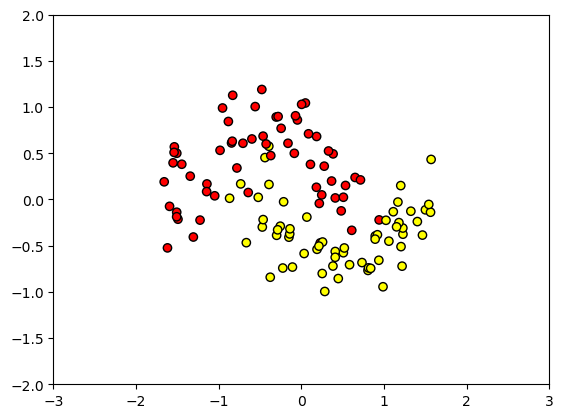

In [2]:
dataset, validation_set = torch.load("two_moons.pt")
X_train, y_train = dataset.tensors
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='autumn', edgecolor='k');
plt.xlim(-3,3)
plt.ylim(-2,2)
plt.show()

## We'll use the following simple feedforward network.

In [3]:
class TwoMoonsNetwork(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 100),
                        nn.ReLU(), 
                        nn.Linear(100, 10),
                        nn.ReLU(),
                        nn.Linear(10, 1))
        
    def forward(self, x):
        h = self.net(x)
        return torch.sigmoid(h).squeeze(1)
    
network = TwoMoonsNetwork()

# TASK 1 (5 points): Define the likelihood and the prior

Let $x_i \in \mathbb{R}^2$ denote an input, $y_i \in \{ 0, 1\}$ a target, and $\theta$ the network parameters.

Let $\hat y_i = f_\theta(x_i)$ denote the output of the network $f_\theta$.

You need to define:

* `log_likelihood`, evaluating a Bernoulli distribution $$\log p(y|x, \theta) = \log \mathrm{Bernoulli}(y | f_\theta(x));$$
* `log_prior`, evaluating a standard normal distribution $$\log p(\theta) = \log \mathcal{N}(\theta | 0, I).$$

Both of these functions should return a numeric scalar value.

For the prior, you will need to somehow access the parameters of the network! There are several ways of doing this. I suggest looking at the pytorch documentation for either

* iterating through `network.parameters()`, or
* using helper functions such as `nn.utils.parameters_to_vector`



In [4]:
def log_likelihood(network, X, y):
    """
    This function computes the log probability `log p(y | x, theta)`
    for a batch of inputs X.
    
    INPUT:
    network : instance of classifier network, extends `nn.Module`
    X       : batch of inputs; torch.FloatTensor, matrix of shape = (batch_size, 2)
    y       : batch of targets: torch.FloatTensor, vector of shape = (batch_size,)
    
    OUTPUT:
    lp      : log probability value of log p(y | x, theta); scalar
    
    """
    # YOUR CODE HERE
    
    # Get the predicted probabilities from the network 
    y_hat = network(X)   #the shape is (batch_size, )

    # Create a Bernoulli distribution parametrized by the predicted probabilities
    bernoulli_dist = dist.Bernoulli(probs=y_hat)

    # Compute the log prob of the targets under the Bernoulli distribution
    log_probs = bernoulli_dist.log_prob(y) #shape is (batch_size,)

    # Sum the log probs over the batch to get a scalar
    lp = log_probs.sum()

    return lp

In [ ]:
# grading


In [5]:
def log_prior(network):
    """
    This function computes the log prior `log p(\theta)`
    assuming a standard normal prior over all network parameters.

    INPUT:
    network : instance of classifier network, extends `nn.Module`

    OUTPUT:
    log_prior_value      : log prior value of log p(\theta); scalar
    """
    # Get all parameters of the network as a single vector
    params = nn.utils.parameters_to_vector(network.parameters()) 

    # Compute the log prior assuming a standard normal distribution mean=0, variance=1
    log_prior_value = -0.5 * torch.sum(params ** 2)  #ignoring the constant term

    return log_prior_value

In [ ]:
# grading


In [ ]:
# grading


# TASK 2 (3 points): Minibatching

Minibatching is "trickier" when we have a prior on the network parameters.

The function `log_joint_minibatch` should return a mini-batch estimate of the log joint of the full data, i.e. returning an estimator of $$\log p(\theta) + \sum_{i=1}^N \log p(y_i | x_i, \theta)$$ but which is evaluated on only the specified subset of the $N$ data points.

In [6]:
def log_joint_minibatch(network, X_batch, y_batch, N_training):
    """ Return a minibatch estimate of the full log joint probability 
    
    INPUT:
    network    : instance of classifier network, extends `nn.Module`
    X_batch    : batch of inputs; torch.FloatTensor, matrix of shape = (batch_size, 2)
    y_batch    : batch of targets: torch.FloatTensor, vector of shape = (batch_size,)
    N_training : total number of training data instances in the full training set

    OUTPUT:
    lp : return an estimate of log p(y, theta | X), as computed on the batch; scalar.

    """
    # YOUR CODE HERE
    
    # Compute the log prior
    lp_prior = log_prior(network)

    # Compute the log likelihood for the batch
    log_like_batch = log_likelihood(network, X_batch, y_batch)

    # Scale the batch log likelihood to approximate the full dataset's contribution
    batch_size = X_batch.size(0)
    log_like_full = log_like_batch * (N_training / batch_size)

    # Combine the prior and scaled likelihood
    return lp_prior + log_like_full

In [ ]:
# grading


In [ ]:
# grading


## Self-diagnostic

This is a small-enough dataset that we can compute the log joint probability on the whole dataset:

In [7]:
with torch.no_grad():
    full_data_lp = log_prior(network) + log_likelihood(network, X_train, y_train)
print("Full data log probability: %0.4f" % full_data_lp.item())

Full data log probability: -113.2695


### In the next cell, we call `log_joint_minibatch`.

If all the code is working correctly, the minibatch estimates should be roughly normally-distributed around the true value!

Changing the batch size should not change the mean of this distribution. Try running the cell below several times.

If the histogram is far away from the true value (the black vertical dashed line), then you probably have a bug.

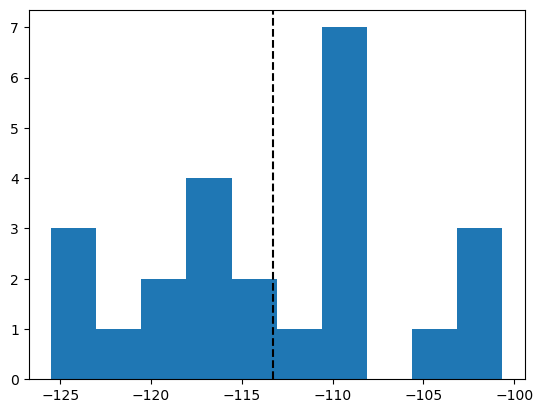

In [8]:
dataloader = torch.utils.data.DataLoader(dataset, shuffle=True, batch_size=5)

with torch.no_grad():
    batch_lp_est = [log_joint_minibatch(network, X, y, len(dataset)).item() for X, y in dataloader]
plt.hist(batch_lp_est, bins=10);
yl = plt.ylim()
plt.plot(full_data_lp.item()*np.ones(2), [0, plt.ylim()[1]], 'k--')
plt.ylim(yl);
# torch.stack(batch_lp_est).sum()
plt.show()

In [9]:
# Added comment
# The plot computes estimates of the log joint probability for each minibatch 
# histogram shows the variability of the estimates. the dashed line marks the full data log joint prob computed earlier for comparison
# The minibatch estimates fluctuate because they are based on small subsets of the data. 
# This fluctuation reflects the stochasticity introduced by minibatching, especially when using small batch sizes.

## Train the model (MAP estimation)

Run the following cell to train your model, to find a MAP estimate.

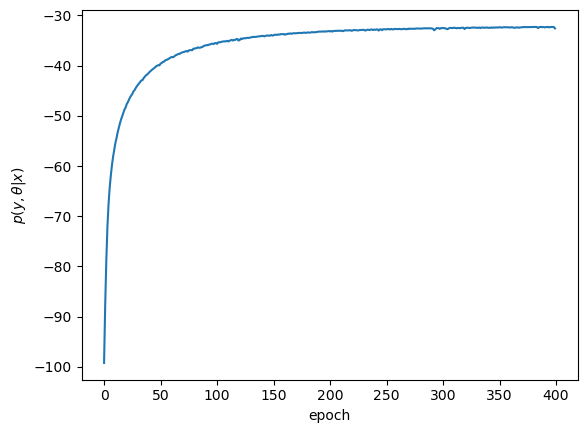

In [10]:
dataloader = torch.utils.data.DataLoader(dataset, shuffle=True, batch_size=5)
opt = torch.optim.Adam(network.parameters())

N_epochs = 400
train_lp = []

for epoch in range(N_epochs):
    for X, y in dataloader:
        opt.zero_grad()
        loss = -log_joint_minibatch(network, X, y, len(dataset))
        loss.backward()
        opt.step()
    with torch.no_grad():
        train_lp.append((log_likelihood(network, X_train, y_train) + log_prior(network)).item())
plt.plot(train_lp)
plt.xlabel("epoch")
plt.ylabel("$p(y, \\theta | x)$");
plt.show()

In [11]:
# Added comment
# During training, the network parameters are updated by maximizing the log joint probability
# Training progresses for N_epochs, and the log joint probability for the full data is recorded at each epoch in train_lp.
# the plot shows how the full data log joint probability improves as traning progresses: 
# - log prior: encourages regularization by penalizing large parameter values
# - log likelihood: encourages the network to fit the data
# map estimation balances

## Confidence plot

To visualize the result, we'll look at a *confidence plot*.

The *confidence* is the probability assigned to whichever class is predicted.

If the most likely class is "yellow", then it shows $p(y = \text{yellow})$. If the most likely class is red, it shows $p(y = \text{red})$.



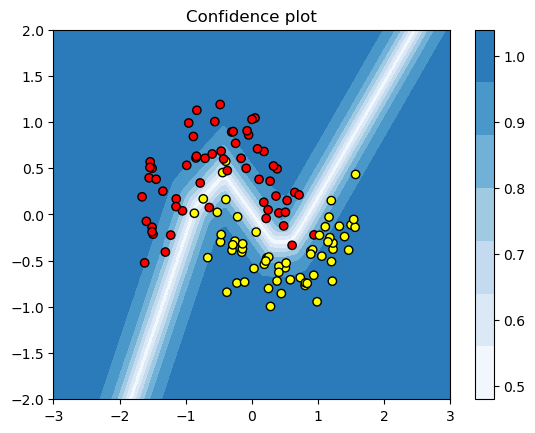

In [12]:
XX, YY = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-2, 2, 100))
with torch.no_grad():
    py = network(torch.FloatTensor(np.stack((XX.ravel(), YY.ravel())).T))
    conf = torch.where(py > 0.5, py, 1-py) ## THIS LINE COMPUTES THE CONFIDENCE
    ZZ = conf.reshape(XX.shape)
CS = plt.contourf(XX, YY, ZZ, cmap='Blues', vmin=0.5, vmax=1.2)
plt.colorbar(ticks=np.linspace(0.5, 1, 6))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='autumn', edgecolor='k')
plt.title("Confidence plot");
plt.show()

In [13]:
# Added comment
# conf = torch.where(py > 0.5, py, 1-py) computes the confidence as the probability assigned to the predicted class
# the plot visualizes the confidence for each point in the input space. 
# This visualization highlights the model’s ability to classify points with high confidence.
# Lighter regions (near 1.0 confidence) show areas where the model is very certain of its prediction, while darker regions indicate lower confidence.

# Calibration and reliability diagrams

I've implemented a reliability diagram plot and expected calibration error computation here.

Could be interesting to see how the number of bins affects the result…!

In [14]:
def reliability_diagram(y, y_hat, N_bins=10):
    """
    Plot a reliability diagram
    """
    bins = torch.linspace(0, 1, N_bins+1)
    which_bin = (y_hat[:,None] >= bins[1:]).long().sum(-1).numpy()
    freq = [y[which_bin==k].mean().item() for k in range(N_bins)]
    conf = [y_hat[which_bin==k].mean().item() for k in range(N_bins)]
    plt.bar(bins[1]/2+np.arange(N_bins)/N_bins, freq, width=bins[1]*.9);
    plt.plot(conf, freq, 'o-', color='k')
    plt.plot([0, 1], [0, 1], '--', color='#333');
    plt.show()

def expected_calibration_error(y, y_hat, N_bins=10):
    """
    Compute the expected calibration error
    """
    bins = torch.linspace(0, 1, N_bins+1)
    which_bin = (y_hat[:,None] >= bins[1:]).long().sum(-1).numpy()
    counts = []
    acc = []
    conf = []
    for k in range(N_bins):
        count = len(y[which_bin==k])
        if count > 0:
            acc.append(y[which_bin==k].mean().item())
            conf.append(y_hat[which_bin==k].mean().item())
        else:
            acc.append(0.0)
            conf.append(0.0)
        counts.append(count)
    return ((np.abs(np.array(acc) - np.array(conf))*np.array(counts))/len(y)).sum()

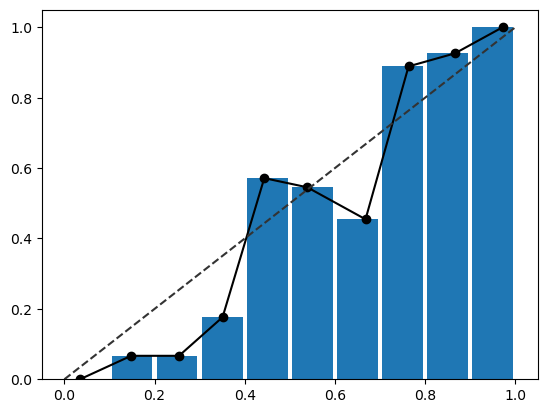

ECE = 0.0536


In [15]:
with torch.no_grad():
    y_hat = network(validation_set.tensors[0])

reliability_diagram(y=validation_set.tensors[1], y_hat=y_hat)
print("ECE = %0.4f" % expected_calibration_error(validation_set.tensors[1], y_hat))
plt.title("Reliability diagram");

In [ ]:
# ADDED 
# Reliability diagram
# The reliability diagram compares confidence (x-axis) to empirical accuracy (y-axis) across N_bins confidence intervals.
# The black line connects the observed accuracy for each bin to show how well the model’s predicted probabilities are calibrated.
# The diagonal line (y=x) represents perfect calibration, where confidence matches accuracy.

# A well-calibrated model provides probabilities that reflect reality (e.g., if the model predicts 0.8 confidence for class A, class A should occur 80% of the time).
# Miscalibration occurs when the predicted probabilities deviate significantly from the true probabilities.

# EXPECTED CALIBRATION ERROR (ECE)
# The ECE quantifies the difference between confidence and accuracy over all bins, weighted by the number of predictions in each bin.
# Lower ECE values indicate better-calibrated models.

# TASK 3 (6 points): stochastic gradient Langevin dynamics (SGLD)

In this task you can get

* 3 points for implementing the SGLD MCMC update
* 3 points for implementing Monte Carlo prediction

The `SGLD_step` function below should take a current set of network parameters $\theta$, and update them as

$$\theta' = \theta + \frac{\epsilon^2}{2} \nabla_\theta \log p(\theta, y | X) + \epsilon z$$

where $\epsilon$ is a learning rate, $X, y$ are a current mini-batch, and $z \sim \mathcal{N}(0, I)$ and has the same dimensionality as $\theta$.

For more details see the week 7 lecture slides!

Note that you will actually have to **do the update**. The following function does not return anything! Instead, it updates the parameters of the network, similar to how a `torch.optim` optimizer updates the parameters.

In [16]:
def SGLD_step(network, X, y, N_training, epsilon):
    """
    Run one step of SGLD given a mini-batch, and update the parameters of the network.
    
    INPUT:
    network    : instance of classifier network, extends `nn.Module`
    X_batch    : batch of inputs; torch.FloatTensor, matrix of shape = (batch_size, 2)
    y_batch    : batch of targets: torch.FloatTensor, vector of shape = (batch_size,)
    N_training : total number of training data instances in the full training set
    epsilon    : step size / learning rate parameters (scalar)
    """
    # YOUR CODE HERE
    
    # Zero out any existing gradients
    network.zero_grad()

    # Compute the log joint prob
    log_joint = log_joint_minibatch(network, X, y, N_training)

    # Compute the gradients with respect to the network parameters
    log_joint.backward() 

    # Step size 
    step_size = 0.5 * epsilon**2


    # Perform the SGLD update 
    with torch.no_grad(): 
        for param in network.parameters(): 
            noise = torch.randn_like(param) # gaussian noise p 
            param += (epsilon**2 / 2) * param.grad + epsilon * noise

In [ ]:
# grading


In [ ]:
# grading


### Cyclic learning rate 

We're going to use a cyclic learning rate schedule for $\epsilon$, like discussed in the lectures. That function is pre-written, below.

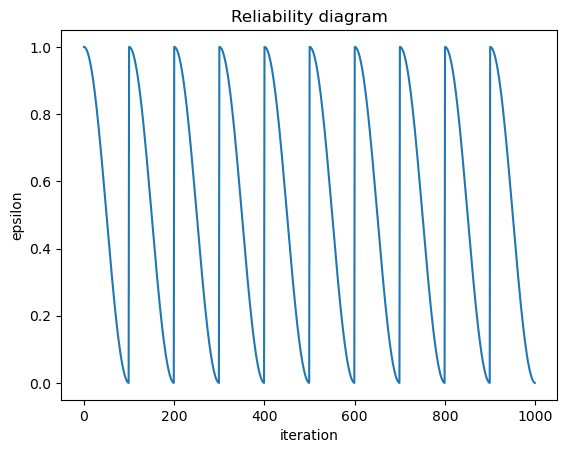

In [17]:
def learning_rate_schedule(N_steps, N_samples, epsilon):
    """
    Pre-compute a learning-rate schedule for SGLD.
    
    INPUT:
    N_steps   : number of SGD updates between each "reset"
    N_samples : number of times we reach the lowest target learning rate
    epsilon   : base learning rate
    
    OUTPUT:
    epsilon_t : vector of length N_steps*N_samples, containing epsilon_t at each iteration t
    """
    return epsilon * (np.cos(np.pi * (np.arange(N_samples*N_steps) % N_steps)/N_steps) + 1)

plt.plot(learning_rate_schedule(N_steps=100, N_samples=10, epsilon=0.5));
plt.xlabel("iteration");
plt.ylabel("epsilon");
plt.show()

### Running the sampler
The following function is also given: it will actually run the SGLD sampler, by calling your `SGLD_step` function above.

In [18]:
def draw_sgld_samples(network, N_samples, N_steps_per_sample, base_epsilon=0.02):
    """
    Draw samples using SGLD, following a prescribed learning rate schedule
    
    OUTPUT:
    samples : torch.FloatTensor, shape = (N_samples, "# of parameters in network")
    """
    lr_schedule = learning_rate_schedule(N_steps_per_sample, N_samples, base_epsilon)
    samples = []
    step = 0
    while True:
        for X, y in dataloader:
            SGLD_step(network, X, y, len(dataset), epsilon=lr_schedule[step])
            step += 1
            if step % N_steps_per_sample == 0:
                samples.append(nn.utils.parameters_to_vector(network.parameters()).detach())
            if step == len(lr_schedule):
                return torch.stack(samples)


In [19]:
samples = draw_sgld_samples(network, N_samples=50, N_steps_per_sample=200)
print("Tensor holding samples of theta has shape:", samples.shape)

Tensor holding samples of theta has shape: torch.Size([50, 1321])


## Making predictions

After running the sampler, you now have a `torch.FloatTensor` which contains many different sampled versions of the network parameters $s = 1,\dots,S$.

To make predictions on an input batch $X$, you will somehow need to "load" in the stored parameters, and run the forward pass using different $\theta^{(s)}$.

In [20]:
def predict_from_samples(X, network, samples):
    """
    
    INPUT:
    X       : batch of input points at which to make predictions; shape = (batch_size, 2)
    network : instance of classifier network, extends `nn.Module`
    samples : torch.FloatTensor containing samples of theta; shape = (num_samples, "# of parameters in network")
    
    OUTPUT:
    y_hat_samples : torch.FloatTensor containing samples of y_hat; shape = (num_samples, batch_size)
    """
    # YOUR CODE HERE
    n_samples = samples.shape[0]
    batch_size = X.shape[0]

    y_hat_samples = torch.zeros((n_samples, batch_size))

    for i, sample in enumerate(samples):
        # load the sample parameters in network
        nn.utils.vector_to_parameters(sample, network.parameters())

        # make predictions with the current sampled parameters 
        with torch.no_grad():
            y_hat = network(X)

        # store the predictions
        y_hat_samples[i] = y_hat

    return y_hat_samples 


In [21]:
# The following should be true if your code is working!
assert predict_from_samples(X_train, network, samples).shape == (samples.shape[0], X_train.shape[0])

In [ ]:
# grading


In [ ]:
# grading


## Confidence plot and reliability diagrams for the Bayesian classifier

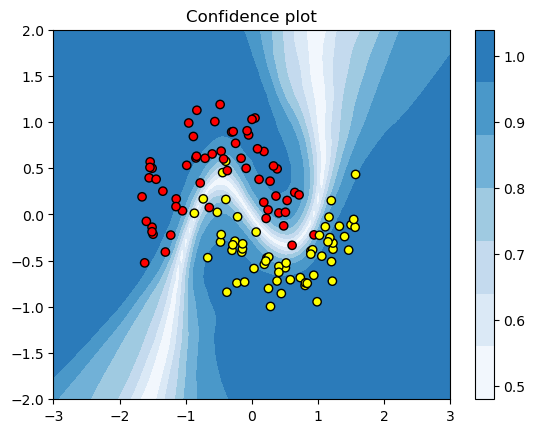

In [22]:
XX, YY = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-2, 2, 100))
with torch.no_grad():
    XXYY = torch.FloatTensor(np.stack((XX.ravel(), YY.ravel())).T)
    out = predict_from_samples(XXYY, network, samples)
    py = out.mean(0)
    conf = torch.where(py > 0.5, py, 1-py)
    ZZ = conf.reshape(XX.shape)
CS = plt.contourf(XX, YY, ZZ, cmap='Blues', vmin=0.5, vmax=1.2)
plt.colorbar(ticks=np.linspace(0.5, 1, 6))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='autumn', edgecolor='k');
plt.title("Confidence plot");
plt.show()

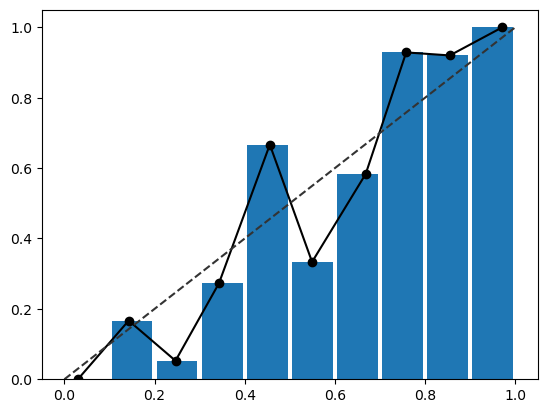

ECE = 0.0488


In [23]:
with torch.no_grad():
    y_hat = predict_from_samples(validation_set.tensors[0], network, samples).mean(0)

reliability_diagram(y=validation_set.tensors[1], y_hat=y_hat)
print("ECE = %0.4f" % expected_calibration_error(validation_set.tensors[1], y_hat))

plt.title("Reliability diagram");

## Uncertainty quantification

We can measure the uncertainty in our predictor by looking at the variance of the predictive distribution

$$p(y | \hat y).$$

Here, $\hat y$ is the posterior mean: the average $p(y = 1)$ estimated across all posterior samples.

The total predictive variance of $y$ is the variance of this distribution, i.e.

$$Var [ y | x ] = Var \left [ \int p(y | x, \theta)p(\theta | \mathcal{D}) d\theta \right]$$

One way to estimate epistemic and aleatoric uncertainty is to look at the variance of $\hat y$, i.e. the variance in $f_\theta(x)$ under the posterior over $\theta$. This corresponds to epistemic uncertainty. The difference between these two is then roughly the aleatoric uncertainty.

There are probably better ways to compute (and explain!) this, but hopefully the following plots look clear.

In [24]:
# Variance of predictive distribution over y
var_of_prediction = dist.Bernoulli(out.mean(0)).variance

# Epistemic uncertainty: Variance across values of y_hat
var_of_mean = out.var(0)

### Darker colors are more uncertain:

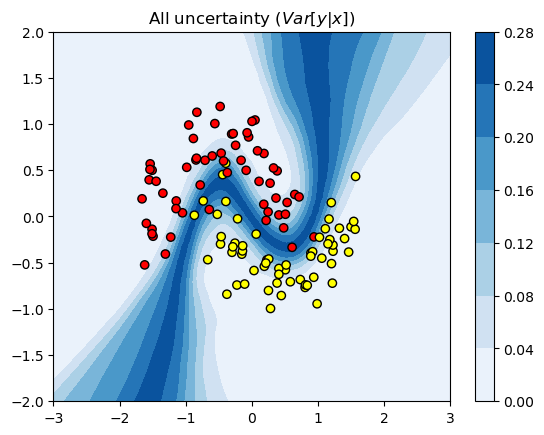

In [25]:
plt.title("All uncertainty ($Var[y | x]$)")
plt.contourf(XX, YY, var_of_prediction.reshape(XX.shape), cmap='Blues', vmin=0, vmax=0.3)
plt.colorbar();
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='autumn', edgecolor='k');
# - torch.sigmoid(out).var(0).reshape(XX.shape))
plt.show()

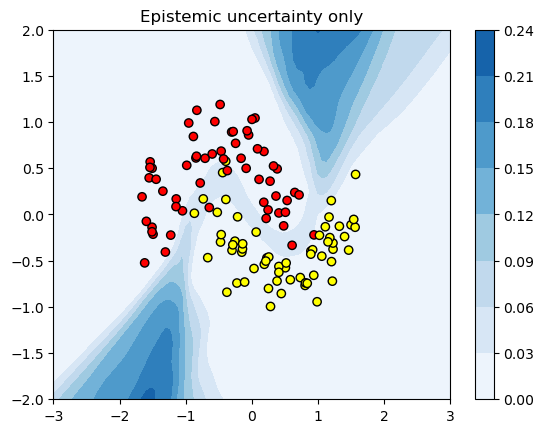

In [26]:
plt.title("Epistemic uncertainty only")
plt.contourf(XX, YY, var_of_mean.reshape(XX.shape), cmap='Blues', vmin=0, vmax=0.28)
plt.colorbar();
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='autumn', edgecolor='k');
plt.show()

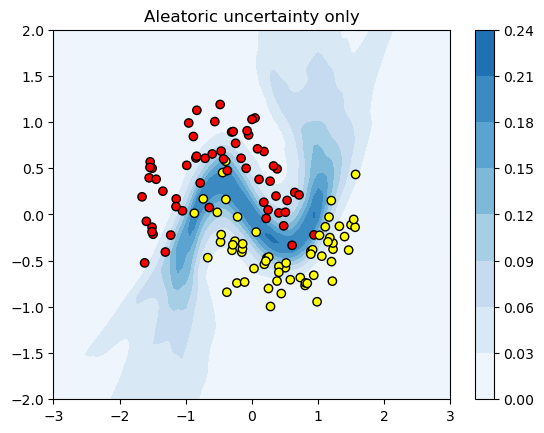

In [27]:
plt.title("Aleatoric uncertainty only")
plt.contourf(XX, YY, (var_of_prediction - var_of_mean).reshape(XX.shape), cmap='Blues', vmin=0, vmax=0.3)
plt.colorbar();
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='autumn', edgecolor='k');
plt.show()

# TASK 4 (up to 5 points, free response): Interpretation

Take a look at Figure 1 in the paper https://arxiv.org/pdf/2002.10118.pdf, "Being Bayesian, Even Just a Bit, Fixes Overconfidence in ReLU Networks", Kristiadi et al. 2020.

1. (4 points) Qualitatively, the uncertainty in figure 1 probably looks quite different from your plots in this notebook. Try to give two different reasons for why the results here might be different.
2. (1 point) What is going on with calibration / temperature scaling? Why doesn't the temperature scaling help in Figure 1 in the paper, and why doesn't the ECE improve in this case when we do sampling?

#### QUESTION 1
The difference in the uncertainty between figure 1 in the paper and the results obtained in this notebook could be related to two main factors:

- The Bayesian approximation implemented 

In the paper, the authors use a Laplace approximation to model a Gaussian posterior over the weights, either applied to the entire network or just the last layer. 
This approach explicitly models uncertainty in the weight parameters with the Gaussian covariance matrix that controls how uncertainty is propagated:  far from the training data, the covariance spreads out the uncertainty making the model less confident.
In contrast, we implement SGLD to sample from the posterior. This approach is more sensitive to factors such as the number of samples, step size and the noise scale.
    -- Number of samples: In our implementation, the number of samples (50) is relatively small. More samples and iterations might be required to accurately represent the posterior and capture uncertainty.
    -- Step size and noise scale: if the step size is too small, SGLD may sample only around the MAP estimate, failing to explore the parameter space thoroughly. This leads to uncertainty estimates that do not differ much from the MAP solution. 
As a result, the uncertainty we observe in out plots decreases mainly around the decision boundary, but fails to capture increased uncertainty far from the training data. 

- Uncertainty in the out of distribution regions

A key focus of the paper is on uncertainty behavior in the regions far from the training data.  
The plots in Figure 1 show high confidence near the training data and gradually decreasing confidence as we move away. This happens because the Gaussian prior over weigths ensures that the network assigns bounded confidence (that is away from 1) to inputs that are far from the training data. 
This behaviour is evident in the plots in the bottom row of Figure 1, where confidence approaches 0.5 as the distance from the training points increases.
In our approach, as above mentioned, confidence remains high in regions far from the training data, likely due to two reasons:
     - ReLU architecture: as discussed in the paper, ReLU networks tend to exhibit arbitrarily high confidence far away from the training data because of the linearity of their output in extreme regions. If the SGLD does not sufficiently explore the parameter space, this overconfidence persists.
     - SGLD does not explicitly enforce low confidence in far regions because it relies on posterior sampling, which may fail to adequately capture the true posterior's behaviour far from the data. 

#### QUESTION 2

- Temperature scaling is a technique that adjusts the model's confidence while preserving the decision boundary.
A higher temperature reduces confidence (flattens the softmax probabilities) and improves calibration for in distribution data.  However, it does not help with the overconfidence issue far away from the training data
The paper explicitly highlights the limitation: temperature scaling fails to detect or properly account for out-of-distribution points because it lacks a Bayesian mechanism or structured uncertainty to reflect uncertainty outside the training data. Indeed, the chosen temperature value (far from 1) scales up the predicted probability of the most probable class while scaling down others, maintaining overconfidence.
- Expected Calibration Error measures the discrepancy between the model’s confidence and its accuracy. 
The weight uncertainty introduced by SGLD may not be large enough to reduce confidence in far regions unless the posterior is well-sampled and well-spread and sufficient uncertainty is captured far from the data. 
Moreover, averaging predictions via posterior sampling reduces variance but does not necessarily align predicted probabilities with true accuracy, leaving the model poorly calibrated.
Since ECE is computed on the seen training data that have larger uncertainty with SGLD sampling, there is not improvement in ECE. 